In [6]:
import logging
import pathlib
import pickle
from functools import partial

import flax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from pachner_traversal.data_io_dehydration import Dataset, Encoder
from pachner_traversal.transformer import MinimalTrainState, Transformer
from pachner_traversal.utils import data_root

logger = logging.getLogger(__name__)

In [7]:
@partial(jax.jit, static_argnames=["vocab_size"])
def get_test_loss(
    state: MinimalTrainState,
    test_batch_input: jax.Array,
    test_batch_label: jax.Array,
    vocab_size: int,
):
    test_logits = state.apply_fn(
        {"params": state.params},
        test_batch_input,
        training=False,
    )

    test_one_hot_labels = jax.nn.one_hot(test_batch_label, num_classes=vocab_size)
    test_loss = optax.softmax_cross_entropy(test_logits, test_one_hot_labels)
    return test_loss.mean(axis=1)


def init_model(
    save_path: pathlib.Path, dataset: Dataset, encoder: Encoder
) -> tuple[MinimalTrainState, int]:
    vocab_size = len(encoder.char_to_id)
    d_model = 512
    num_layers = 6
    num_heads = 4
    seq_len = dataset.max_len + 1
    learning_rate = 0.0005

    key = jax.random.PRNGKey(0)
    _, dropout_key = jax.random.split(key)

    model = Transformer(
        vocab_size=vocab_size,
        d_model=d_model,
        block_size=seq_len,
        num_layers=num_layers,
        num_heads=num_heads,
    )

    with open(save_path / "params.pkl", "rb") as file:
        params = pickle.load(file)

    state = MinimalTrainState.create(
        params=params,
        apply_fn=model.apply,
        dropout_key=dropout_key,
        learning_rate=learning_rate,
        m_tm1=flax.core.freeze(  # type: ignore
            jax.tree_util.tree_map(jnp.zeros_like, params)
        ),
        v_tm1=flax.core.freeze(  # type: ignore
            jax.tree_util.tree_map(jnp.zeros_like, params)
        ),
        t=0,
        tx=optax.adamw(learning_rate=learning_rate, weight_decay=0.01),
    )

    return state, vocab_size

In [8]:
file_path = data_root / "input_data" / "dehydration" / "processed" / "spheres_10.hdf5"
save_path = (
    data_root
    / "results"
    / "sgd_models_dehydration"
    / "archive"
    / "output"
    / "spheres_512emb_6block_4head_10tet"
    / "20260422_1900"
)

dataset = Dataset(file_path, 1_000)
encoder = Encoder(dataset)

state, vocab_size = init_model(save_path, dataset, encoder)

ERROR:2026-05-07 10:41:11,572:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dbruwel/miniconda3/envs/honours-sage/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dbruwel/miniconda3/envs/honours-sage/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dbruwel/miniconda3/envs/honours-sage/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA lib

In [9]:
def read_encode(path, nlines=1_000):
    data = []

    with open(path) as f:
        for _ in range(nlines):
            line = f.readline()
            if not line:
                break

            line = line.strip()
            data.append(line)

    encoded = encoder.encode(data)

    return encoded

In [10]:
# import pandas as pd
# from regina import Triangulation3

# data = pd.read_csv('/home/dbruwel/main/honours/pachner_graph_triangulations/temp.csv', index_col=0)
# data = data.dropna()
# data = data.to_numpy()
# data = np.unique(data)
# data = data.astype(str)
# data = data[np.char.startswith(data, 'k')]

# data = data[:1000]
# assert len(data) == 1000

# data = [Triangulation3.fromIsoSig(iso).dehydrate() for iso in data]

# for s in data:
#     print(s)

In [11]:
def get_losses(m_type):
    path = data_root / "input_data" / "dehydration" / "raw" / "manifold_difference" / f"{m_type}.txt"
    encoded = read_encode(path)
    losses = get_test_loss(
        state,
        encoded[0],
        encoded[1],
        vocab_size,
    )
    losses = np.array(losses)

    return losses

In [12]:
res = {}

for m_type in ["l71", "l72", "rp3", "s2s1", "s3"]:
    print(m_type)
    res[m_type] = get_losses(m_type)

l71
l72
rp3
s2s1
s3


In [13]:
from scipy import stats
special = 's3'
control_group = res[special]
other_groups = [res[k] for k in res if k != special]
other_names = [k for k in res if k != special]

# 3. Perform Dunnett's Test
# We use alternative='greater' because we expect the OTHER groups
# to have a GREATER mean than special.
stat_res = stats.dunnett(*other_groups, control=control_group, alternative='greater')

# 4. View Results
print(f"{'Comparison':<15} | {'P-Value':<10} | {'Significant?'}")
print("-" * 45)
for i, name in enumerate(other_names):
    p_val = stat_res.pvalue[i]
    is_sig = p_val < 0.05
    print(f"special vs {name:<8} | {p_val:.4f}     | {is_sig}")

Comparison      | P-Value    | Significant?
---------------------------------------------
special vs l71      | 0.0000     | True
special vs l72      | 0.0000     | True
special vs rp3      | 0.0000     | True
special vs s2s1     | 0.0004     | True


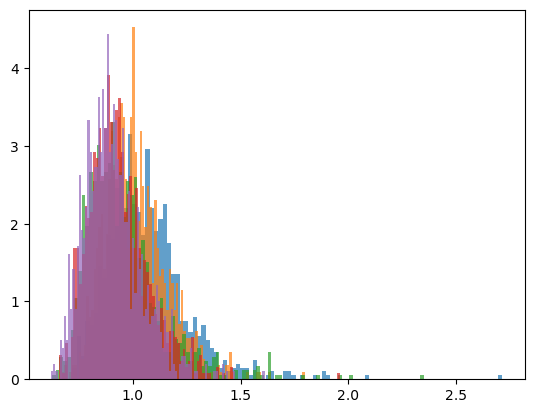

In [14]:
for m_type in ["l71", "l72", "rp3", "s2s1", "s3"]:
    plt.hist(res[m_type], bins=100, alpha=0.7, density=True, label=m_type)
plt.show()